<a href="https://colab.research.google.com/github/muskan-dhawan/DSA-ML-GEN-AI/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Split training data into train and validation sets
x_val = x_train[-5000:].astype("float32")
y_val = y_train[-5000:].reshape(-1)

x_train = x_train[:-5000].astype("float32")
y_train = y_train[:-5000].reshape(-1)

x_test = x_test.astype("float32")

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot vectors
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test.reshape(-1), 10)

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping callback
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1670s 10us/step
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.3506 - loss: 1.8040 - val_accuracy: 0.4536 - val_loss: 1.4650
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4554 - loss: 1.5095 - val_accuracy: 0.5448 - val_loss: 1.2654
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5059 - loss: 1.3751 - val_accuracy: 0.5526 - val_loss: 1.2353
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5481 - loss: 1.2768 - val_accuracy: 0.6490 - val_loss: 0.9798
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5732 - loss: 1.2064 - val_accuracy: 0.6430 - val_loss: 1.0378
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5999 - loss: 1.1504 - val_accuracy: 0.6322 - val_loss: 1.0810
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6219 - loss: 1.0996 - val_accuracy: 0.6434 - val_loss: 1.0893
313/313 - 2s - 5ms/step - accuracy: 0.6

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist # Changed from cifar10
from tensorflow.keras.utils import to_categorical

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Reshape data to include channel dimension for grayscale images (28, 28, 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Split training data into train and validation sets
x_val = x_train[-5000:].astype("float32")
y_val = y_train[-5000:].reshape(-1)

x_train = x_train[:-5000].astype("float32")
y_train = y_train[:-5000].reshape(-1)

x_test = x_test.astype("float32")

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot vectors
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test.reshape(-1), 10)

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)), # Updated input shape for Fashion MNIST
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping callback
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7291 - loss: 0.7432 - val_accuracy: 0.8254 - val_loss: 0.4790
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8103 - loss: 0.5282 - val_accuracy: 0.8566 - val_loss: 0.3839
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8348 - loss: 0.4597 - val_accuracy: 0.8610 - val_loss: 0.3727
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8474 - loss: 0.4274 - val_accuracy: 0.8526 - val_loss: 0.3855
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8554 - loss: 0.4051 - val_accuracy: 0.8548 - val_loss: 0.3838
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8628 - loss: 0.3813 - val_accuracy: 0.8858 - val_loss: 0.3113
Epoch 7/10
860/860 ━━━━━━━━━━━━━

Shape of x_test: (10000, 32, 32, 3)
Shape of y_test: (10000, 10)


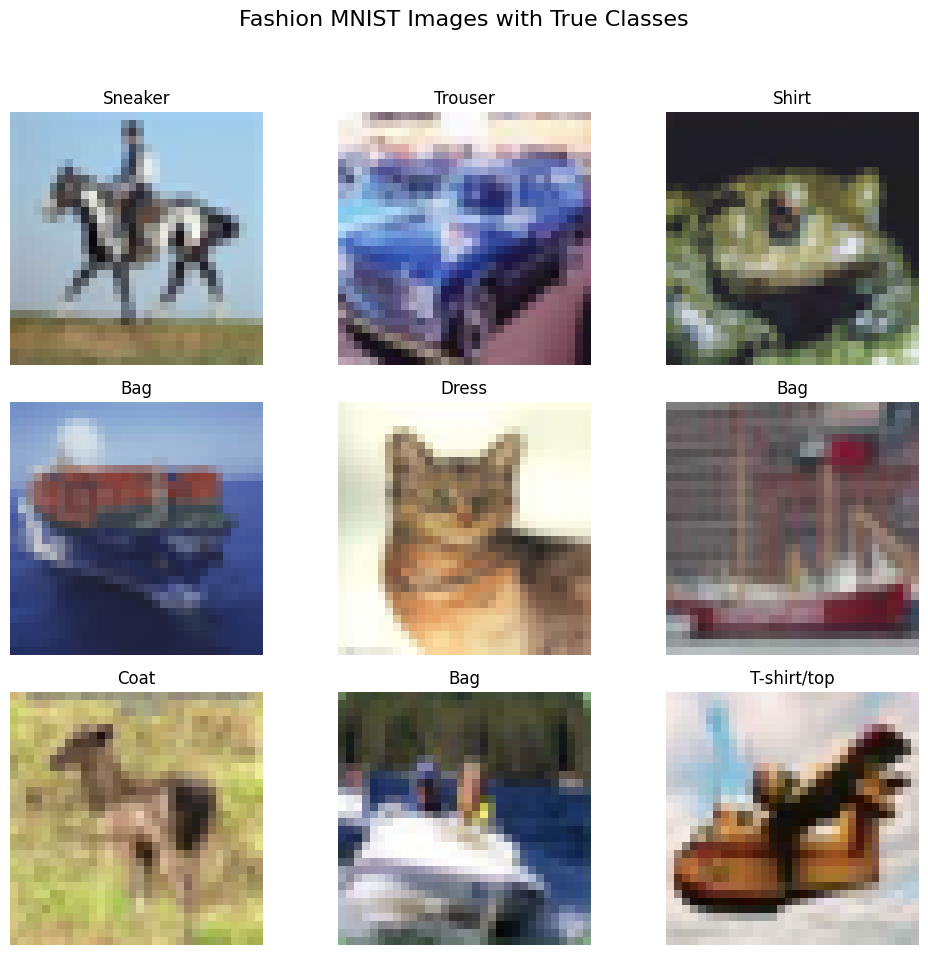

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define Fashion MNIST class names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Print the shape of x_test to help debug
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Select a few random images from the test set
num_images_to_show = 9
random_indices = np.random.choice(x_test.shape[0], num_images_to_show, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    # Use .squeeze() to remove the channel dimension if it exists and is 1 (e.g., from (28, 28, 1) to (28, 28))
    # This allows imshow to correctly interpret it as a grayscale image.
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(class_names[np.argmax(y_test[idx])])
    plt.axis('off')
plt.suptitle('Fashion MNIST Images with True Classes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

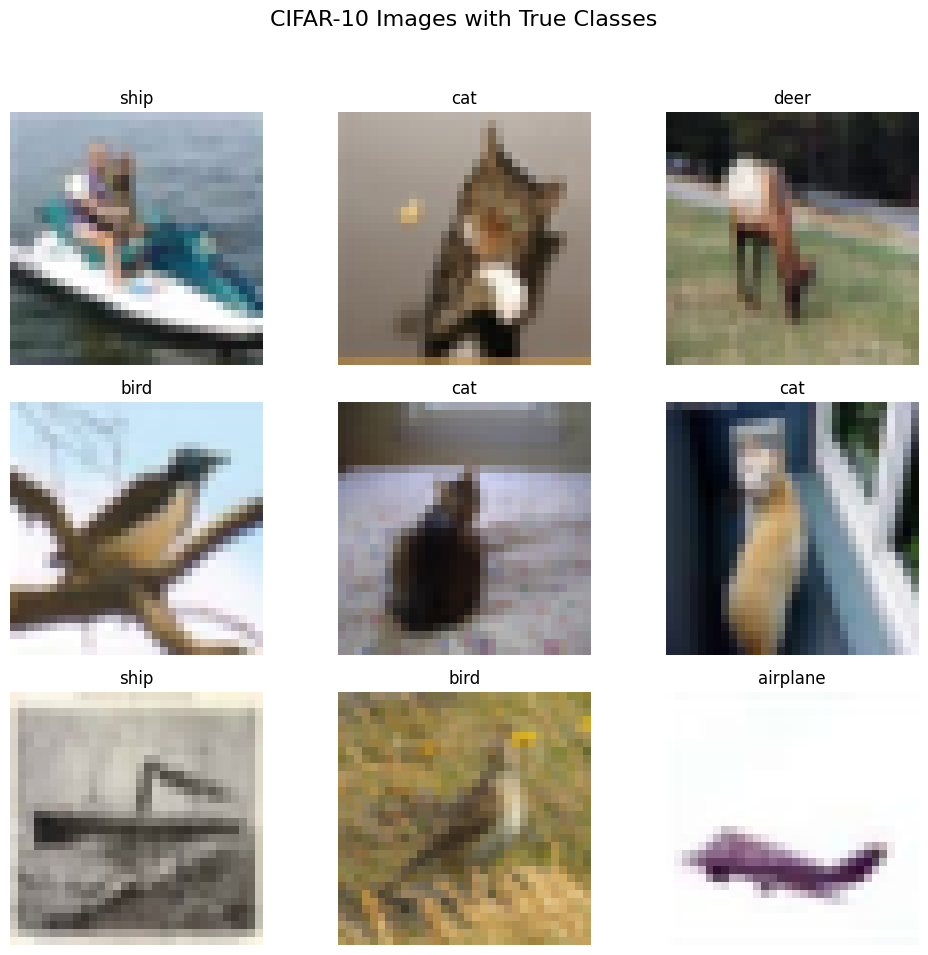

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10 # Load CIFAR-10 specifically for this cell

# Load only the test set for visualization to avoid overwriting existing training data
(_, _), (x_cifar_test, y_cifar_test) = cifar10.load_data()

# Define CIFAR-10 class names
cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalize pixel values to [0, 1] for display
x_cifar_test = x_cifar_test.astype('float32') / 255.0

# Select a few random images from the CIFAR-10 test set
num_images_to_show = 9
random_indices_cifar = np.random.choice(x_cifar_test.shape[0], num_images_to_show, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices_cifar):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_cifar_test[idx]) # CIFAR-10 images are (32, 32, 3)
    plt.title(cifar_class_names[y_cifar_test[idx][0]])
    plt.axis('off')
plt.suptitle('CIFAR-10 Images with True Classes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape data to include channel dimension for grayscale images (28, 28, 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Split training data into train and validation sets
x_val = x_train[-5000:].astype("float32")
y_val = y_train[-5000:].reshape(-1)

x_train = x_train[:-5000].astype("float32")
y_train = y_train[:-5000].reshape(-1)

x_test = x_test.astype("float32")

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot vectors
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test.reshape(-1), 10)

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)), # Updated input shape for Fashion MNIST
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping callback
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8243 - loss: 0.5467 - val_accuracy: 0.9676 - val_loss: 0.1064
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9249 - loss: 0.2517 - val_accuracy: 0.9730 - val_loss: 0.0978
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9423 - loss: 0.1977 - val_accuracy: 0.9728 - val_loss: 0.0999
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9507 - loss: 0.1654 - val_accuracy: 0.9808 - val_loss: 0.0708
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9565 - loss: 0.1513 - val_accuracy: 0.9696 - val_loss: 0.1245
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9589 - loss: 0.1401 - val_accuracy: 0.9820 - val_loss: 0.0690
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9610 - loss: 0.1351 - val_accuracy: 0.9824 - val_loss: 0.0647
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━

## Confusion Matrix for MNIST Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


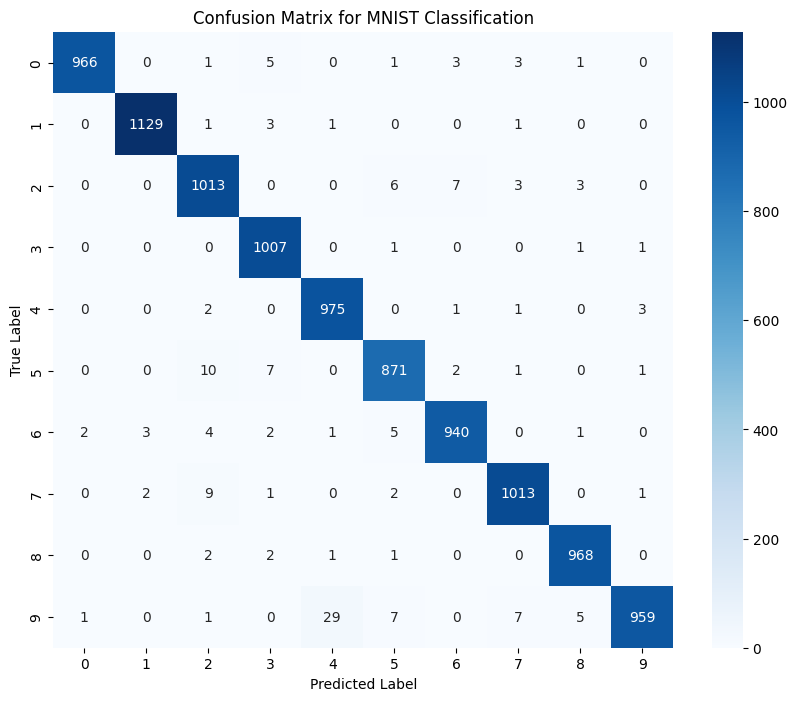

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions for the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for MNIST Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Sample Predictions on MNIST Test Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


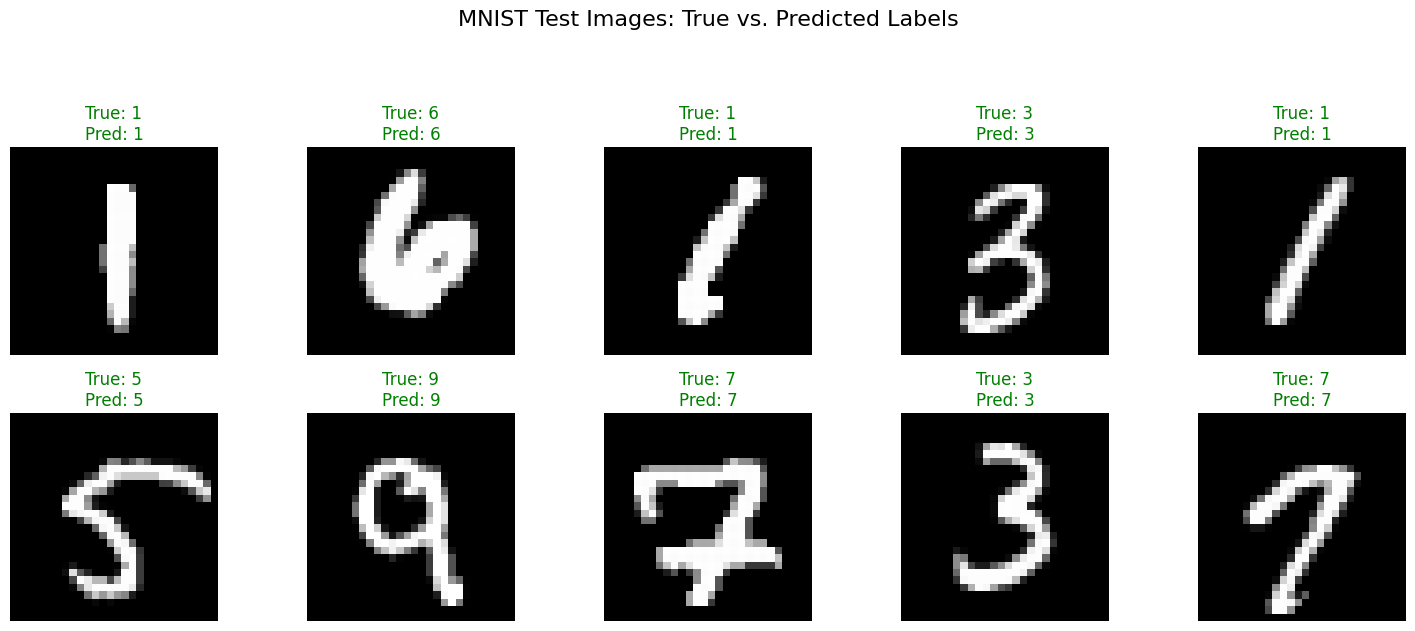

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get predictions from the model
predictions = model.predict(x_test)

# Define MNIST class names (digits 0-9)
mnist_class_names = [str(i) for i in range(10)]

num_images = 10  # Number of images to display

plt.figure(figsize=(15, 15))
for i in range(num_images):
    # Select a random image index
    idx = np.random.randint(0, len(x_test))

    # Get the image, true label, and predicted label
    image = x_test[idx].reshape(28, 28) # Reshape for imshow
    true_label = np.argmax(y_test[idx])
    predicted_label = np.argmax(predictions[idx])

    plt.subplot(5, 5, i + 1)
    plt.imshow(image, cmap='gray')
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"True: {mnist_class_names[true_label]}\nPred: {mnist_class_names[predicted_label]}", color=color)
    plt.axis('off')

plt.suptitle('MNIST Test Images: True vs. Predicted Labels', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()